In [57]:
import sys
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import logging
from patsy import bs
import itertools

# Setup logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

In [58]:
# Configuration

MODE = '06'

if MODE == '06':
    base_path = Path('firemen/firepoint/2x2/train/occurence_062023/check_z-score/full_all_3_0_zonemeteo_node/')
    parent_dir_name = 'full_all_3_0_zonemeteo_node/'
    path_baseline = Path('06/')
elif MODE == 'bdiff':
    pass
elif MODE == 'firemen':
    pass

scale = 10
horizon = 0

clustering = 'quantile'

models = [
    'GRU_search_full_10_0_all_one_',
]

losses = [
    #'regression_pdegpd',
    #'classification_flwki-id{departement}',
    'classification_flwk',
    'classification_weightedcrossentropy',
    'classification_wkloss',
    'regression_cll',
    'classification_bceloss',
    'classification_fl',
    'corn_cornloss',
    'corn_cornfl',
]

targets = [
   f'nbsinister-{clustering}-5-Class-Dept',
   f'timeintervention-{clustering}-5-Class-Dept',
   f'ressource-{clustering}-5-Class-Dept',
]

all_dir = list(itertools.product(models, losses, targets))

In [59]:
import os
import io
import pandas as pd
import paramiko

def list_remote_pkl_files(sftp, remote_dir):
    pkl_files = []

    # 1) essayer remote_dir/H0/*.pkl
    h0_dir = remote_dir.rstrip("/")
    try:
        for f in sftp.listdir(h0_dir):
            if f.endswith(".pkl"):
                pkl_files.append(h0_dir + "/" + f)
    except FileNotFoundError:
        pass

    # 2) sinon remote_dir/*.pkl
    if not pkl_files:
        try:
            for f in sftp.listdir(remote_dir):
                if f.endswith(".pkl"):
                    pkl_files.append(remote_dir.rstrip("/") + "/" + f)
        except FileNotFoundError:
            pass

    return pkl_files

def read_remote_pickle(sftp, remote_file_path):
    # Lire le fichier distant dans un buffer mémoire puis le donner à pandas
    with sftp.open(remote_file_path, "rb") as f:
        data = f.read()
    return pd.read_pickle(io.BytesIO(data))

def find_remote_directories(sftp, base_path_remote, all_dir):
    matches = []

    # Vérifie que base_path_remote existe
    try:
        sftp.listdir(base_path_remote)
    except FileNotFoundError:
        print(f"Base path does not exist on remote: {base_path_remote}")
        return []

    for (model, loss, target) in all_dir:
        print(model, loss, target)
        dir_name = f"{model}{target}_{loss}"
        full_path = base_path_remote.rstrip("/") + "/" + dir_name
        try:
            # Si listdir marche, c'est un dossier existant
            sftp.listdir(full_path)
            matches.append((full_path, model, loss, target))
        except FileNotFoundError:
            continue

    return matches

# --- Connexion SSH ---
hostname = "mesohelios1.univ-fcomte.fr"
username = "ncaron"
password = "xp2nrfeu"
#key_path = "/chemin/vers/id_rsa"  # si clé

ssh = paramiko.SSHClient()
ssh.set_missing_host_key_policy(paramiko.AutoAddPolicy())
ssh.connect(hostname, username=username, password=password)

sftp = ssh.open_sftp()

# --- Utilisation ---
base_path_remote = (Path("/Home/Users/ncaron/WORK/GNN") / base_path).as_posix()
directories = find_remote_directories(sftp, base_path_remote, all_dir)
print(f"Found {len(directories)} directories matching configuration.")

all_data_frames = {}

for d, model, loss, target in directories:
    if target not in all_data_frames.keys():
        all_data_frames[target] = {}
    if target is None:
        continue

    pkl_files = list_remote_pkl_files(sftp, d)
    if not pkl_files:
        continue

    file_path = pkl_files[0]
    
    try:
        res = read_remote_pickle(sftp, file_path)
    except Exception as e:
        print(f"Error loading {d}: {e}")
        continue
    
    all_data_frames[target][f'{model}_{loss}'] = res    
sftp.close()
ssh.close() 

INFO:paramiko.transport:Connected (version 2.0, client OpenSSH_8.0)
INFO:paramiko.transport:Authentication (publickey) failed.
INFO:paramiko.transport:Authentication (publickey) failed.
INFO:paramiko.transport:Authentication (password) successful!
INFO:paramiko.transport.sftp:[chan 0] Opened sftp connection (server version 3)


GRU_search_full_10_0_all_one_ classification_flwk nbsinister-quantile-5-Class-Dept
GRU_search_full_10_0_all_one_ classification_flwk timeintervention-quantile-5-Class-Dept
GRU_search_full_10_0_all_one_ classification_flwk ressource-quantile-5-Class-Dept
GRU_search_full_10_0_all_one_ classification_weightedcrossentropy nbsinister-quantile-5-Class-Dept
GRU_search_full_10_0_all_one_ classification_weightedcrossentropy timeintervention-quantile-5-Class-Dept
GRU_search_full_10_0_all_one_ classification_weightedcrossentropy ressource-quantile-5-Class-Dept
GRU_search_full_10_0_all_one_ classification_wkloss nbsinister-quantile-5-Class-Dept
GRU_search_full_10_0_all_one_ classification_wkloss timeintervention-quantile-5-Class-Dept
GRU_search_full_10_0_all_one_ classification_wkloss ressource-quantile-5-Class-Dept
GRU_search_full_10_0_all_one_ regression_cll nbsinister-quantile-5-Class-Dept
GRU_search_full_10_0_all_one_ regression_cll timeintervention-quantile-5-Class-Dept
GRU_search_full_10_0_a

INFO:paramiko.transport.sftp:[chan 0] sftp session closed.


Error loading /Home/Users/ncaron/WORK/GNN/firemen/firepoint/2x2/train/occurence_062023/check_z-score/full_all_3_0_zonemeteo_node/GRU_search_full_10_0_all_one_ressource-quantile-5-Class-Dept_corn_cornfl: No module named 'optuna'


In [60]:
all_data_frames

{'nbsinister-quantile-5-Class-Dept': {'GRU_search_full_10_0_all_one__classification_flwk': {'epoch': [0,
    1,
    2,
    3,
    4,
    5,
    6,
    7,
    8,
    9,
    10,
    11,
    12,
    13,
    14,
    15,
    16,
    17,
    18,
    19,
    20,
    21,
    22,
    23,
    24,
    25,
    26,
    27,
    28,
    29,
    30,
    31,
    32,
    33,
    34,
    35,
    36,
    37,
    38,
    39,
    40,
    41,
    42,
    43,
    44,
    45,
    46,
    47,
    48,
    49,
    50,
    51,
    52,
    53,
    54,
    55,
    56,
    57,
    58,
    59,
    60,
    61,
    62,
    63,
    64,
    65,
    66,
    67,
    68,
    69,
    70,
    71,
    72,
    73,
    74,
    75,
    76,
    77,
    78,
    79,
    80,
    81,
    82,
    83,
    84,
    85,
    86,
    87,
    88,
    89,
    90,
    91,
    92,
    93,
    94,
    95,
    96,
    97,
    98,
    99,
    100,
    101,
    102,
    103,
    104,
    105,
    106,
    107,
    108,
    109,
    110,
    111,
    

In [61]:
import math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker


def plot_sampling_scores(data, target, metrics=None):
    """
    Visualise l'évolution de plusieurs scores en fonction de la proportion de sous-échantillon.
    1 figure unique, 1 subplot par config (3 colonnes), toutes les métriques sur le même subplot.
    Une barre verticale indique la valeur 'best_tp' si elle est présente dans le dict de config.

    Paramètres
    ----------
    data    : dict  – structure : data[target][config][np.float64(tp)] = {metric: array}
    target  : str   – clef cible dans data
    metrics : list  – métriques à afficher (toutes sur le même axe par config)
    """
    if metrics is None:
        metrics = ['iou_val', 'f1_val', 'under_val', 'over_val',
                   'prec_val', 'recall_val', 'auoc_val']

    if target not in data:
        print(f"Target '{target}' not found. Available: {list(data.keys())}")
        return

    target_data = data[target]
    configs = list(target_data.keys())
    if not configs:
        print(f"No config found for target '{target}'.")
        return

    n_configs = len(configs)
    n_cols    = 3
    n_rows    = math.ceil(n_configs / n_cols)

    colors = plt.cm.tab10(np.linspace(0, 1, len(metrics)))
    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(6 * n_cols, 4 * n_rows),
                             squeeze=False,
                             sharex=False)
    fig.suptitle(f"Score evolution by subsample proportion  –  target: {target}",
                 fontsize=13, y=1.01)

    for ci, config_name in enumerate(configs):
        row, col = divmod(ci, n_cols)
        ax = axes[row][col]

        config_dict = target_data[config_name]
        test_pct = config_dict.get('test_percentage', None)
        if test_pct is None:
            ax.set_title(f"{config_name}\n(no test_percentage)", fontsize=8)
            ax.axis('off')
            continue

        any_plotted = False
        for metric, color in zip(metrics, colors):
            xs, means, stds = [], [], []
            for tp in test_pct:
                tp_key = np.float64(tp)
                if tp_key not in config_dict:
                    continue
                arr = config_dict[tp_key].get(metric, None)
                if arr is None or len(arr) == 0:
                    continue
                arr = np.asarray(arr, dtype=float)
                xs.append(float(tp))
                means.append(float(np.mean(arr)))
                stds.append(float(np.std(arr)))

            if not xs:
                continue
            xs    = np.array(xs)
            means = np.array(means)
            stds  = np.array(stds)

            ax.plot(xs, means, marker='o', linewidth=1.5, color=color, label=metric)
            ax.fill_between(xs, means - stds, means + stds, alpha=0.15, color=color)
            any_plotted = True

        if not any_plotted:
            ax.set_title(f"{config_name}\n(no data)", fontsize=8)
            ax.axis('off')
            continue

        # Vertical line at best_tp
        best_tp = config_dict.get('best_tp', None)
        if best_tp is not None:
            ax.axvline(float(best_tp), color='red', linestyle='--', linewidth=1.5,
                       label=f'best_tp={best_tp:.2f}')

        ax.set_xlabel('Subsample proportion', fontsize=9)
        ax.set_ylabel('Score', fontsize=9)
        ax.set_title(config_name, fontsize=8, wrap=True)
        ax.set_xlim(left=0)
        ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=7, loc='best')

    # Hide unused subplots
    for ci in range(n_configs, n_rows * n_cols):
        row, col = divmod(ci, n_cols)
        axes[row][col].axis('off')

    plt.tight_layout()
    plt.show()


# ── Usage ─────────────────────────────────────────────────────────────────────
# plot_sampling_scores(all_data_frames, target='nbsinister-quantile-5-Class-Dept')
# plot_sampling_scores(all_data_frames, target='Fire', metrics=['iou_val', 'auoc_val'])
# ─────────────────────────────────────────────────────────────────────────────

In [64]:
"""for target in targets:
    plot_sampling_scores(all_data_frames, target, ['score_k1_test', 'score_k2_test', 'score_k3_test', 'score_k4_test'])"""

"for target in targets:\n    plot_sampling_scores(all_data_frames, target, ['score_k1_test', 'score_k2_test', 'score_k3_test', 'score_k4_test'])"

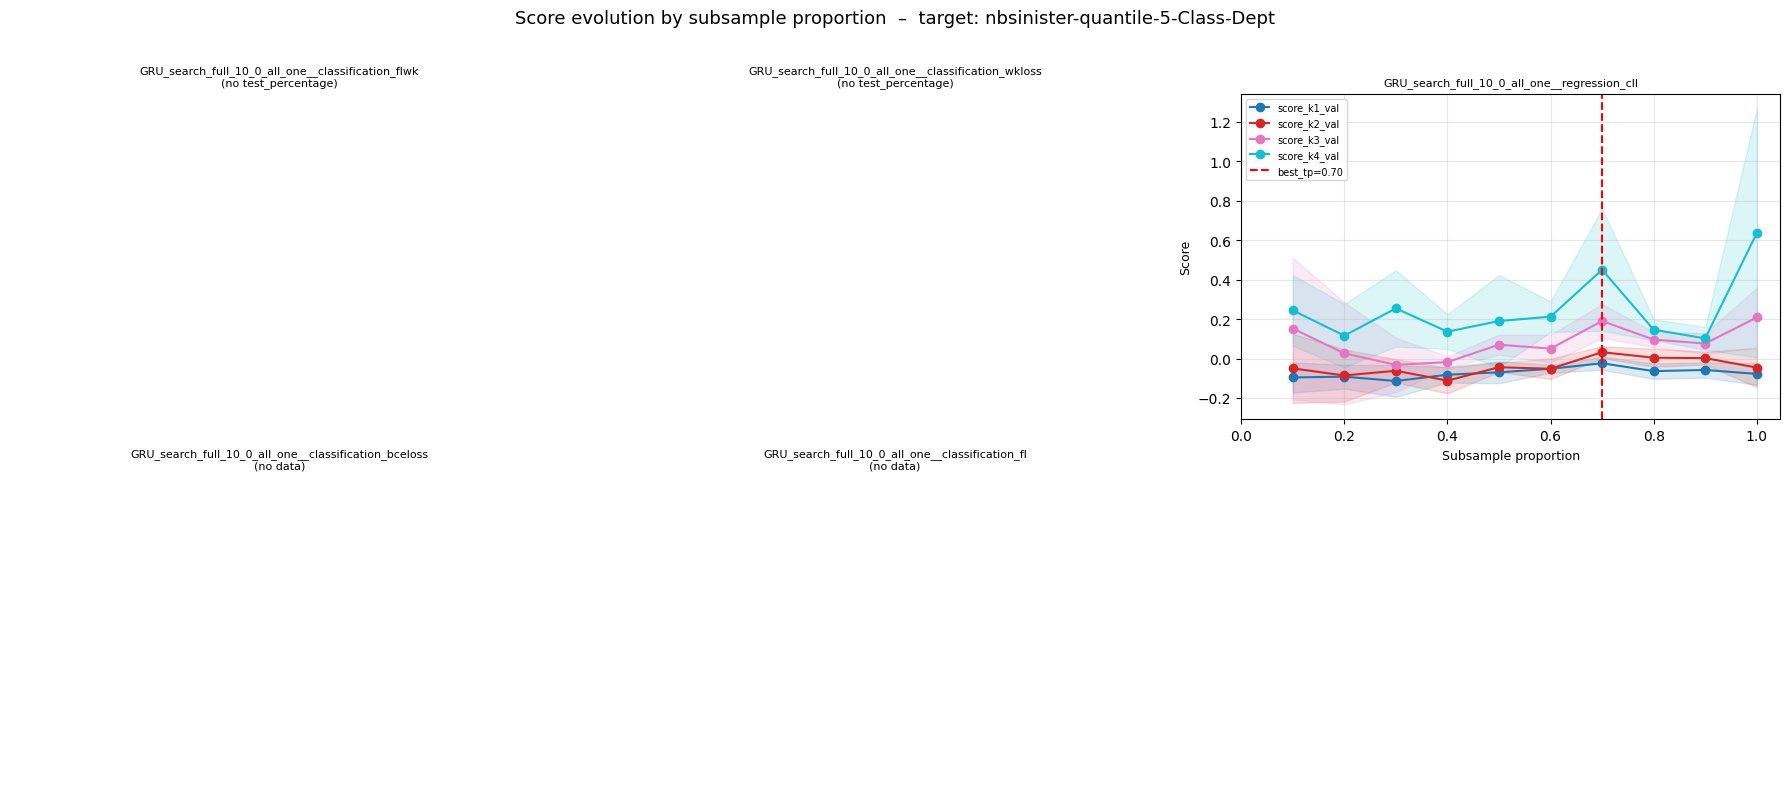

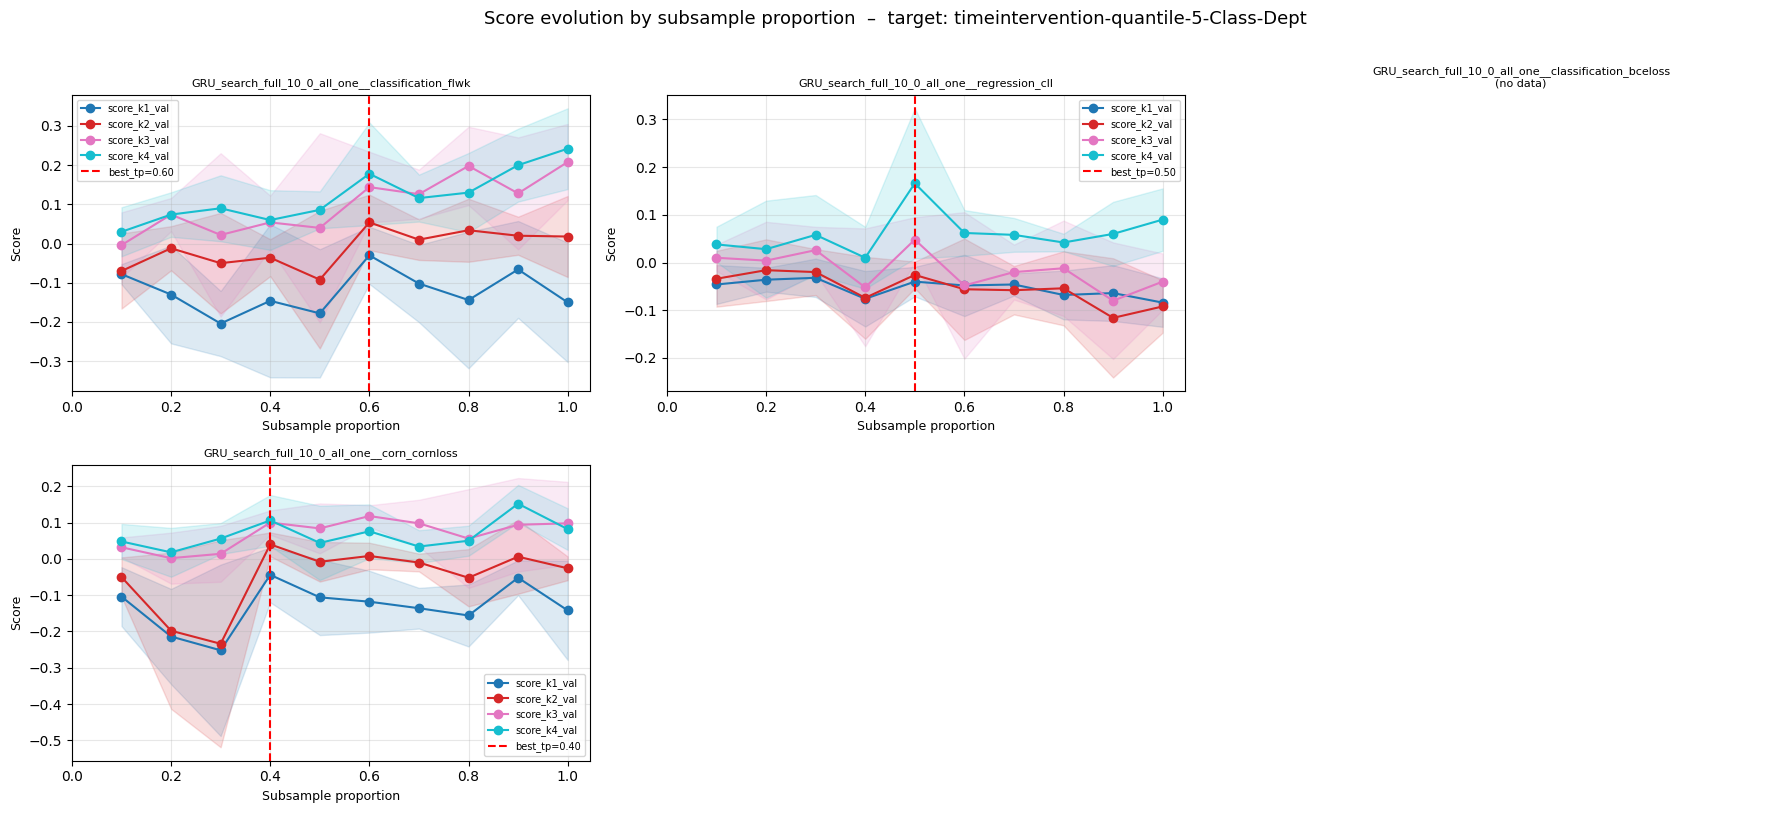

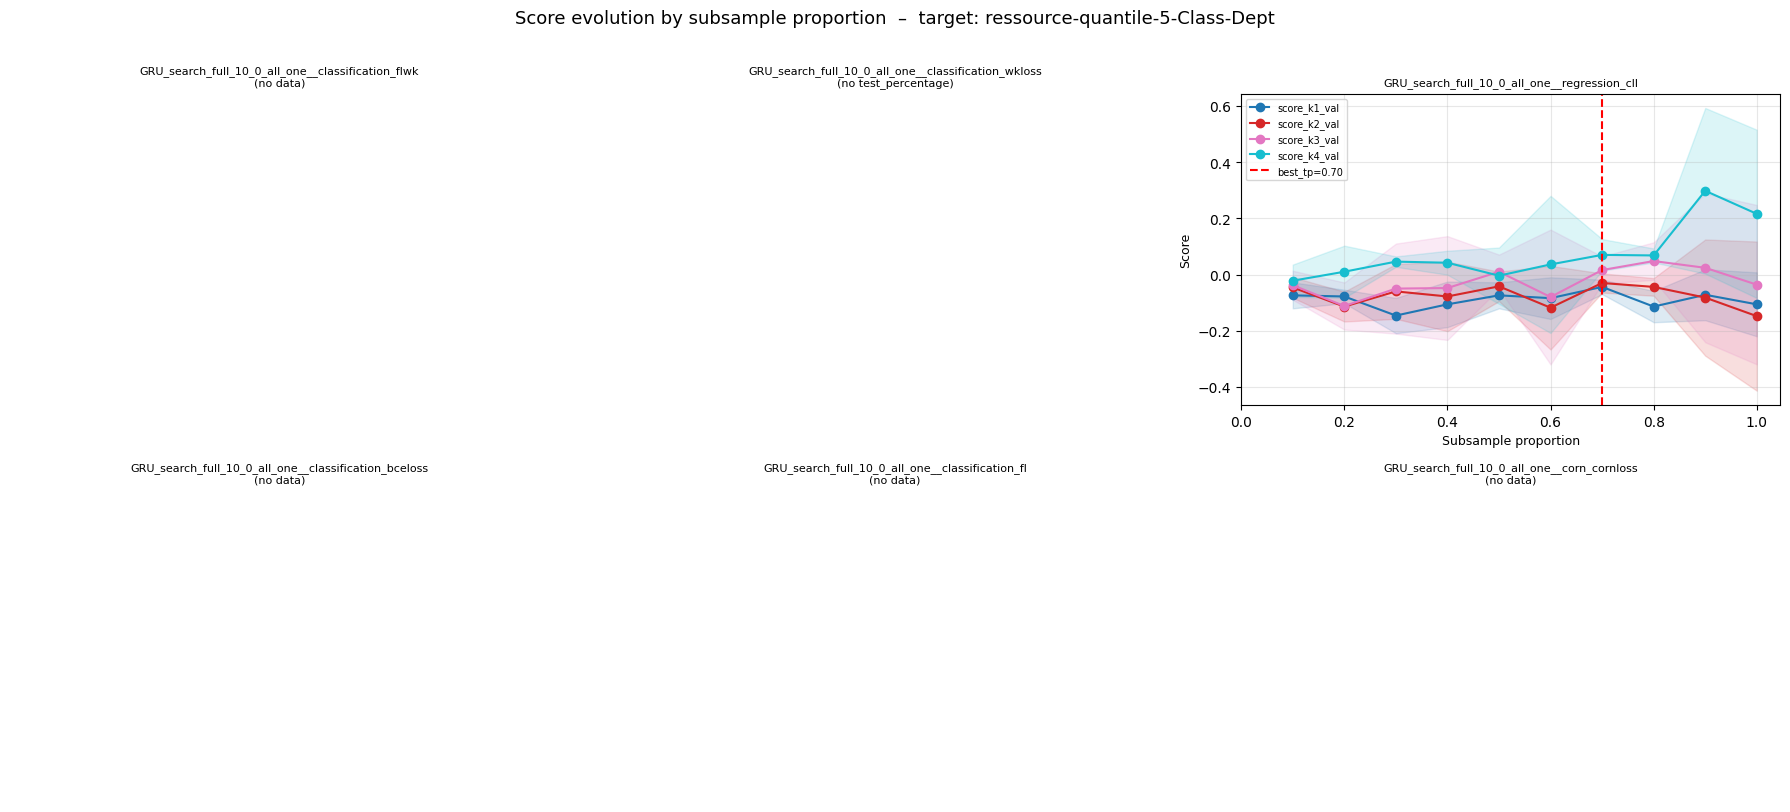

In [63]:
for target in targets:
    plot_sampling_scores(all_data_frames, target, ['score_k1_val', 'score_k2_val', 'score_k3_val', 'score_k4_val'])